# Tipping Points in Psychopathology 

In [1]:
# imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib_inline.backend_inline import set_matplotlib_formats
# set_matplotlib_formats('svg')
from matplotlib import animation
from tqdm import tqdm
import scipy.stats as spstats
from statsmodels.tsa.stattools import grangercausalitytests
#import powerlaw

## Ising Model

In [2]:
class IsingSimulation:

    def __init__(self, network, initial_state=None, H=1.0, J=1.0, T=2.26, length=10_000, warmup=1000):
        """
        Initialises the Ising model simulation

        Parameters:

        network: the network of nodes, where each node is a symptom
        initial_state: the initial state of the system (patient's mind). If nothing is provided, the state will be random

        H: the external field applied on the system - stress
        J: the coupling - how much neighbouring emotions want to align
        T: the temperature/ noise - how strong are random swings from one state to the other
        
        length: the amount of time steps to simulate
        warmup: The amount of steps to take before starting the simulation, to allow the system to settle down
        """

        # The network of nodes, that is the brain of the patient
        self.network = network

        # Transform the network into a numpy array for easier computations down the line
        self.adj_matrix = nx.to_numpy_array(self.network)
        
        # The size of the system N
        self.num_nodes = self.adj_matrix.shape[0]
        
        # The physics that govern the system
        self.H = H # The external stressor
        self.T = T # The noise in the system

        # compute the coupling between emotions so that the default behaviour is a patient with a rigid brain
        # whose emotions are strongly coupled
        # This allows to display a sharp phase transition from healthy to depressed if the external stress is high
        if J is None:

            # degrees of all nodes
            degrees = np.sum(self.adj_matrix, axis=1)
            # largest degree
            max_degree = np.max(degrees)
            
            # we want the nodes with largest degrees to be stable against the noise T
            factor = 2
            self.J = (self.T  / max_degree) * factor
            
            # print(f"computed J: {self.J:.4f}")
        
        else:
        
            self.J = J

        # The initial state of the system
        # If an initial state is not provided we should assign randomly a value in {-1, 1} to each node
        # However if we provide an initial state, the warmup is prohibited since we would be deviating from that initial state
        if initial_state is None:

            self.warmup = warmup
            self.current_state = np.random.choice([-1, 1], size=self.num_nodes)
        
        else:
        
            self.warmup = 0
            self.current_state = np.array(initial_state)

        # The time settings
        self.length = length # the number of time steps to perform

        # The records of the evolution of the simulation
        # Storing the state of each node for all time steps
        self.history = np.zeros((self.length, self.num_nodes), dtype=np.int8)

        # Store the state of each node during the warmup period (for covariance calculations)
        self.warmup_states = np.zeros((self.warmup, self.num_nodes), dtype=np.int8)

        # storing the average mood - order parameter, m, at each time step
        self.order_history = np.zeros(self.length)

        # Storing the external field/Stress applied on the system at each point in time
        self.h_history = np.zeros(self.length)

        # Storing the covariance matrices to compute the eigenvalues later
        self.cov_matrices = None


    def step(self):
        """
        Performs one Monte Carlo step 
        We attempt to flip randomly selected nodes one by one.
        """

        # Loop N times so every node has the chance of being update per time step
        for _ in range(self.num_nodes):

            # Pick a random node
            node_idx = np.random.randint(0, self.num_nodes)
            
            # Identify the current state of that node
            s = self.current_state[node_idx]
            
            # The influence from neighbors
            # Row of Adjacency matrix @ State of all the noodes
            neighbor_sum = np.dot(self.adj_matrix[node_idx], self.current_state)
            
            # The total force applied on this node as per the Ising model
            # Force = (Coupling * Neighbors) + External field
            total_force = (self.J * neighbor_sum) + self.H
            
            # The Energy cost to flip the current node
            delta_E = 2 * s * total_force
            
            # The metropolis decision
            # if the energy decreases then we flip the node immediately
            # if the energy increases then we still have a prob of flipping due to random noise
            if delta_E < 0:

                self.current_state[node_idx] *= -1

            # Flip with probability P = exp(-dE/T)
            elif np.random.random() < np.exp(-delta_E / self.T):
                
                self.current_state[node_idx] *= -1



    def run(self, delta_H=None):
        """
        Runs the model for the specified length of time in the init
        If delta_H is specified, the stress moves up or down at each step. The first value of delta_H is ignored.
        """
        # Save the original H so we can reset it later
        original_H = self.H
        if delta_H is not None:
            if type(delta_H) == np.ndarray:
                if len(delta_H) != self.length:
                    raise ValueError(f"delta_H must be a float or an array with the same length as the simulation length ({self.length})")
            elif type(delta_H) == float:
                delta_H = np.full(self.length, delta_H)
            else:
                raise ValueError(f"delta_H must be a float or an array with the same length as the simulation length ({self.length})")
        
        # Warmup - Settling down from pure random noise
        # Run the physics, but we dont record the data
        for i in range(self.warmup):
            self.step()
            self.warmup_states[i] = self.current_state.copy()
        
        
        # Record the state right after warmup as t=0
        # copy() is necessary so we dont save a reference to the changing array of spins
        self.history[0] = self.current_state.copy()
        self.order_history[0] = self.get_order()
        
        #storing the external field/stress for use in later analysis
        self.h_history[0] = self.H
        
        for t in range(1, self.length):
            # change stress at each time step if requested
            if delta_H is not None:
                self.H += delta_H[t]
            
            # evolve the system one step
            self.step()
            
            # save to the pre-allocated arrays
            self.history[t] = self.current_state.copy()
            self.order_history[t] = self.get_order()
            self.h_history[t] = self.H
        
        # Reset H so the value stays consistent
        self.H = original_H


    def get_order(self):
        """
        Calculates the order parameter, that is, the average mood
        -1 is total depression and +1 is perfect health
        """
        return np.mean(self.current_state)
    
    def order(self):
        """
        Returns the timeline of the variation of the order parameter for each state of the network
        """
        return self.order_history


    def covariance_matrices(self, window=5):
        """
        Get a covariance matrix at each time step using the specified window size.
        The window uses warmup states for early timesteps, then transitions to history states.

        Returns:
            numpy array of shape (length, num_nodes, num_nodes) containing covariance matrices
        """
        if window > self.warmup + self.length:
            raise ValueError(f"Window size ({window}) cannot exceed warmup + length ({self.warmup + self.length})")

        all_states = np.vstack([self.warmup_states, self.history])
        cov_matrices = np.zeros((self.length, self.num_nodes, self.num_nodes))

        for t in range(self.length):
            current_idx = self.warmup + t
            start_idx = max(0, current_idx - window + 1)
            end_idx = current_idx + 1

            window_states = all_states[start_idx:end_idx]
            
            cov_matrices[t] = np.cov(window_states.T)

        # Save the covariance matrices for later use
        self.cov_matrices = cov_matrices
        return cov_matrices

    def sorted_cov_eigens(self):
        """
        Calculates the sorted eigenvalues and eigenvectors of the covariance matrix at each time step.
        """
        if self.cov_matrices is None:
            print("Covariance matrices have not been calculated. Calculating now...")
            self.covariance_matrices()
        
        all_eigenvalues = np.zeros((self.length, self.num_nodes))
        all_eigenvectors = np.zeros((self.length, self.num_nodes, self.num_nodes))
        
        for t, cov in enumerate(self.cov_matrices):
            # Get eigenvalues and eigenvectors
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            
            # Sort in descending order
            sorted_indices = np.argsort(eigenvalues)[::-1]
            
            all_eigenvalues[t] = eigenvalues[sorted_indices]
            all_eigenvectors[t] = eigenvectors[:, sorted_indices]
        
        return all_eigenvalues, all_eigenvectors
    
    def get_early_warning_signal(self):
        """
        Stores the leading eigenvalue for each time step
        This is the specific method Chen et al. use as the warning signal
        
        Returns:
            numpy array
        """
        # Get all eigenvalues (sorted descending)
        eigenvalues, _ = self.sorted_cov_eigens()
        
        # Take the first column (the largest eigenvalue at each step)
        # This represents the variance along the system's most unstable dimension
        max_eigenvalues = eigenvalues[:, 0]
        
        return max_eigenvalues

### Core network

In [3]:
def get_symptom_network(group_size=6, bridge_size=3): # TODO: @Kyle
    # create a Borsboom-style network with n symptoms
    n = group_size*2 + bridge_size
    adj_matrix = np.zeros((n, n))
    # group A
    for i in range(group_size):
        for j in range(group_size + bridge_size):
            adj_matrix[i, j] = 1
    # bridges
    for i in range(group_size, group_size + bridge_size):
        for j in range(n):
            adj_matrix[i, j] = 1
    # group B
    for i in range(group_size + bridge_size, n):
        for j in range(group_size, n):
            adj_matrix[i, j] = 1
    G = nx.from_numpy_array(adj_matrix, create_using=nx.Graph())
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

150


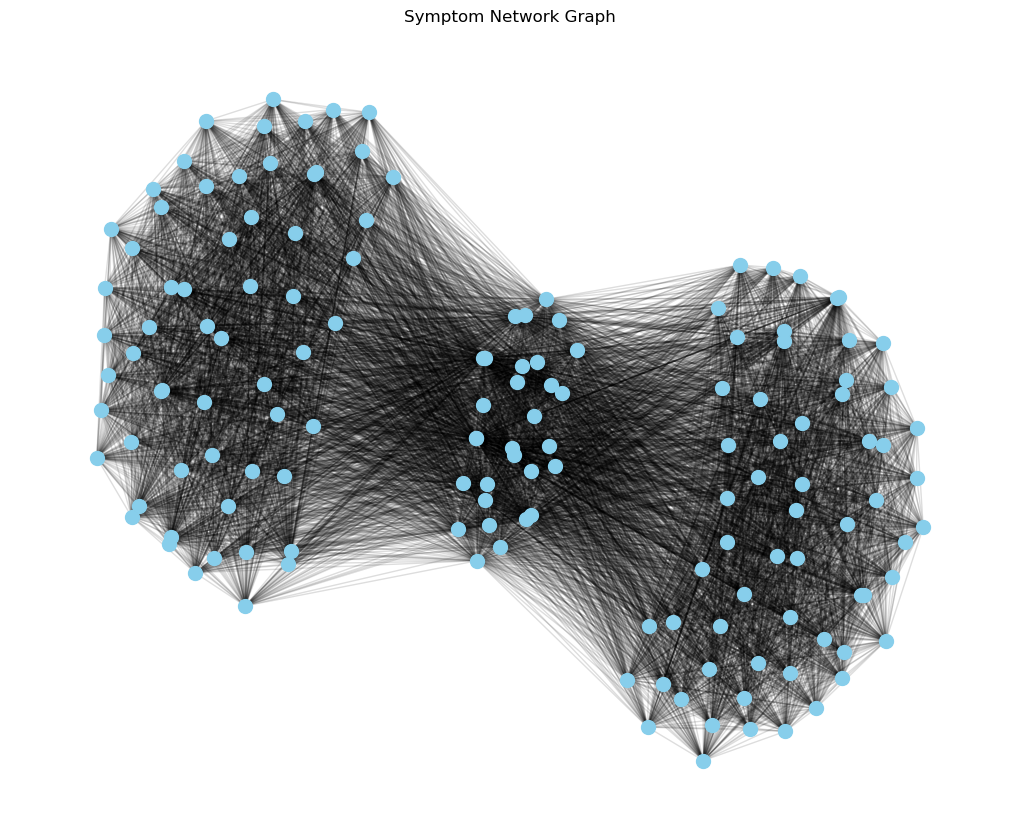

In [4]:
G = get_symptom_network(60, 30)
# G = nx.grid_2d_graph(20, 20, periodic=True)
print(len(G.nodes))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42) 
nx.draw(G, pos, with_labels=False, node_color='skyblue', 
        node_size=100, edge_color='#00000022', font_size=10)
plt.title("Symptom Network Graph")
plt.show()

## Plotting

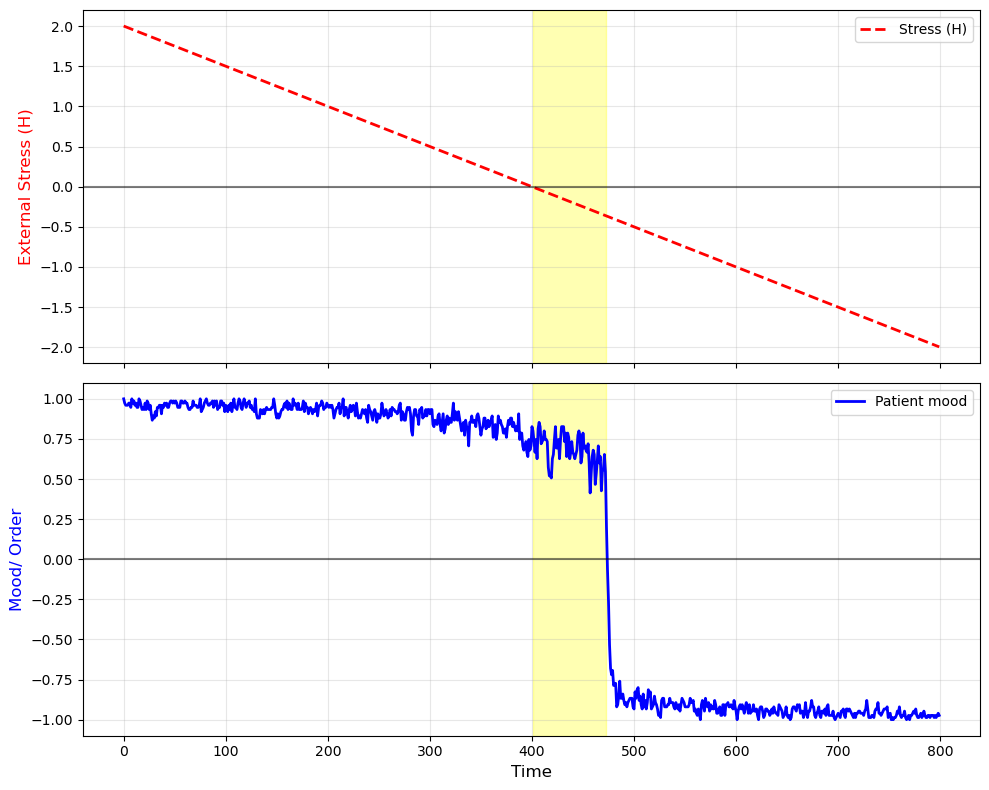

In [5]:
model = IsingSimulation(G, H=2.0, J=None, T=2.269, length=800, warmup=50)

model.run(delta_H=-0.005)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# top plot
ax1.plot(model.h_history, color='red', linestyle='--', linewidth=2, label="Stress (H)")
ax1.axhline(0, color='black', alpha=0.5)
ax1.set_ylabel("External Stress (H)", color='red', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')


# Where the outside stress is negative so unhealthy
bad_environment = model.h_history < 0

# Where the patients mood is still healthy, bellow 0
good_mood = model.order_history > 0

# The points where the stress is negative but the mood is still positive
metastable_indices = np.where(bad_environment & good_mood)[0]

# If there are any points where the above conditions are valid draw a yelow zone
if len(metastable_indices) > 0:
    start = metastable_indices[0]
    end = metastable_indices[-1]
    ax1.axvspan(start, end, color='yellow', alpha=0.3)

# bottom plot
ax2.plot(model.order_history, color='blue', linewidth=2, label="Patient mood")
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel("Mood/ Order", color='blue', fontsize=12)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# Yellow zone of the bottom graph
if len(metastable_indices) > 0:
    ax2.axvspan(start, end, color='yellow', alpha=0.3)


plt.tight_layout()
plt.show()

Covariance matrices have not been calculated. Calculating now...


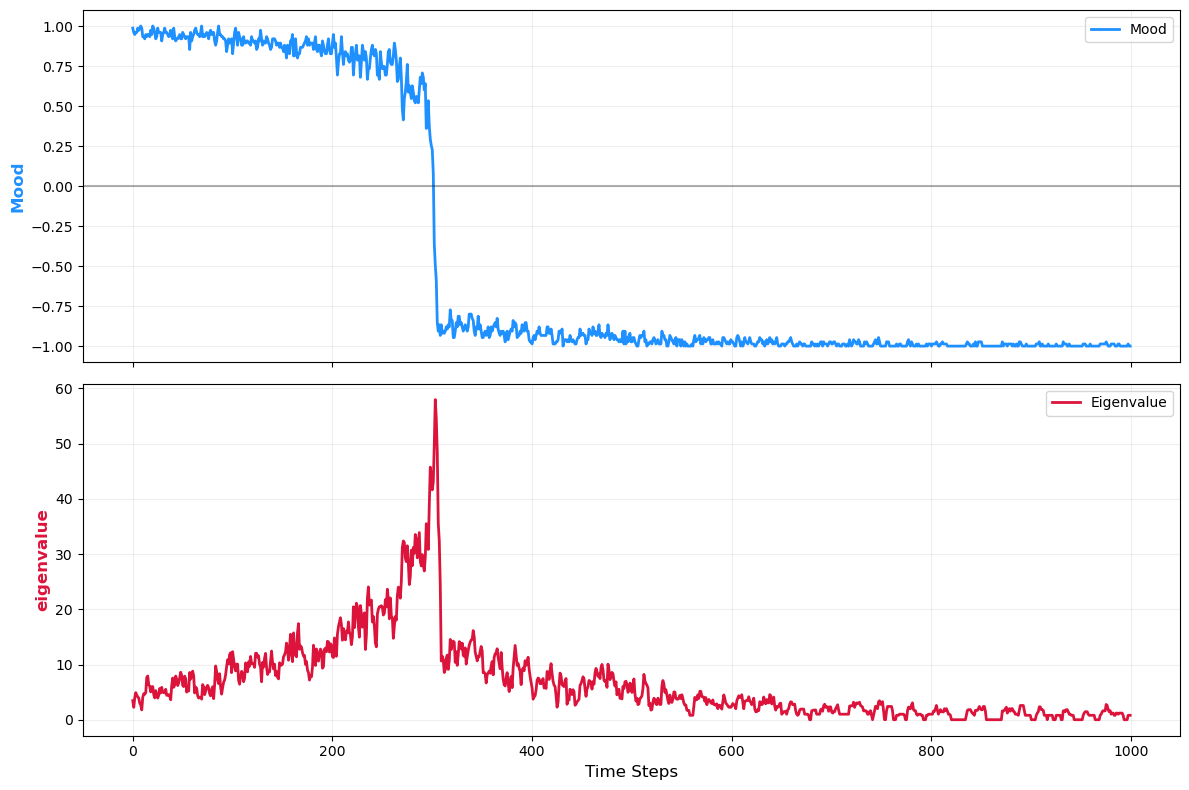

In [6]:
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=1000, warmup=100)


model.run(delta_H=-0.006) 

# ews
warning_signal = model.get_early_warning_signal()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(model.order_history, color='dodgerblue', linewidth=2, label="Mood")
ax1.set_ylabel("Mood", fontsize=12, fontweight='bold', color='dodgerblue')
ax1.axhline(0, color='black', alpha=0.3)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='upper right')


ax2.plot(warning_signal, color='crimson', linewidth=2, label="Eigenvalue")
ax2.set_ylabel("eigenvalue", fontsize=12, fontweight='bold', color='crimson')
ax2.set_xlabel("Time Steps", fontsize=12)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')


plt.tight_layout()
plt.show()

running
computing covariance and ews
Covariance matrices have not been calculated. Calculating now...


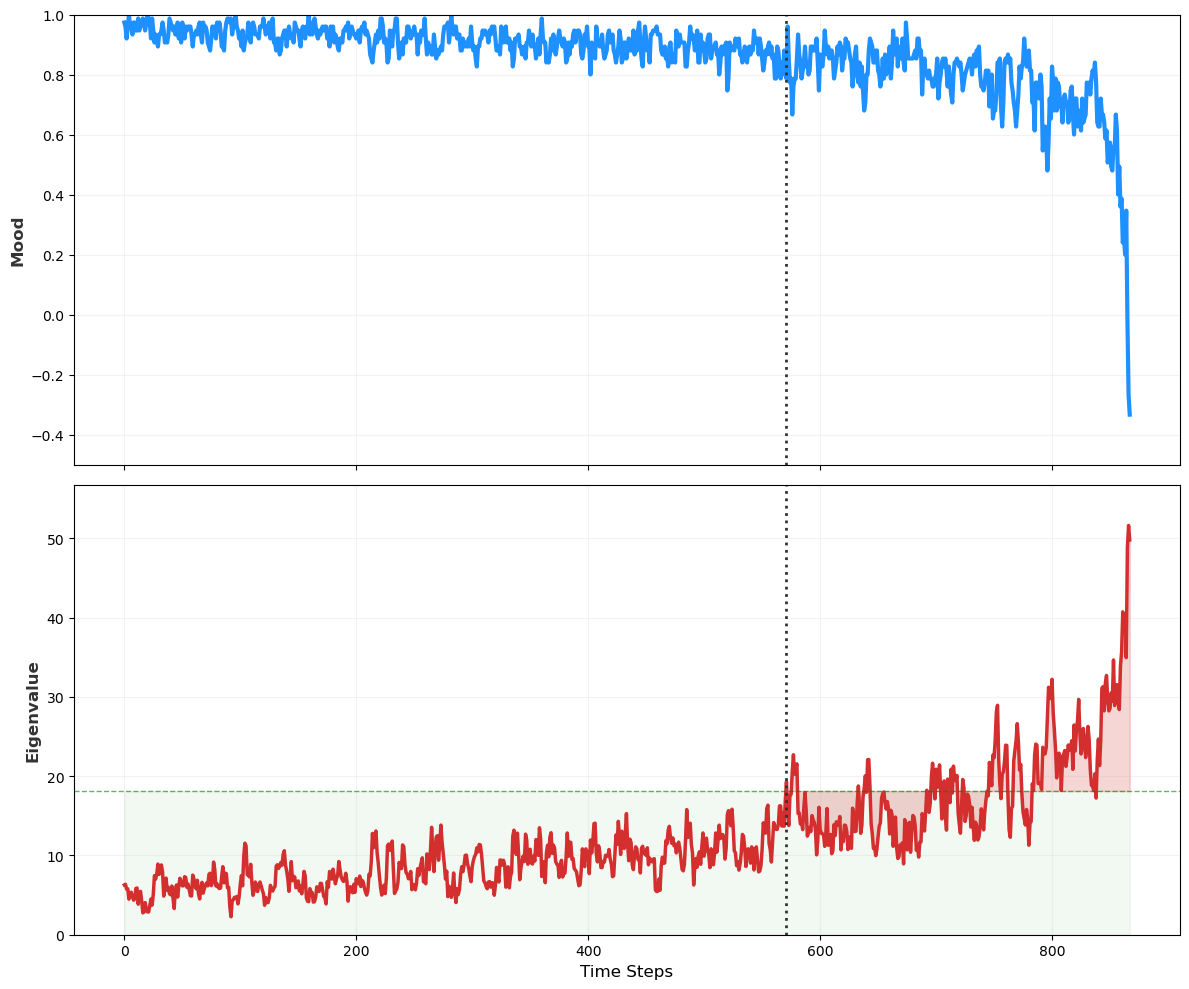

In [7]:
# the lower delta_H allows the patient to stay more time in the yellow zone, 
# which makes the covariance better at predicting fluctuations from the baseline
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=2000, warmup=100)

print("running")
model.run(delta_H=-0.002) 

# computing the covariance matrices and obtaining the time series with the early warning signal
print("computing covariance and ews")
warning_signal = model.get_early_warning_signal()

# finding a better way to describe the ews increase by only showing data up to the crash
crash_indices = np.where(model.order_history < -0.5)[0]
if len(crash_indices) > 0:
    cut_point = crash_indices[0] 


# slice data
time_axis = np.arange(cut_point)
mood_data = model.order_history[:cut_point]
signal_data = warning_signal[:cut_point]

# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# mood
ax1.plot(time_axis, mood_data, color='dodgerblue', linewidth=3, label="Patients mood")
ax1.set_ylabel("Mood", fontsize=12, fontweight='bold', color='#333333')
ax1.set_ylim(-0.5, 1.0) # focus on positie mood values
ax1.grid(True, alpha=0.15)

# the signal
# calculate the baseline average from the first 500 steps and the standard deviation
baseline_mean = np.mean(signal_data[:500])
baseline_std = np.std(signal_data[:500])

# 4 sigma above the average
threshold = baseline_mean + (4 * baseline_std) 

# plot the eigenvalue
ax2.plot(time_axis, signal_data, color='#D32F2F', linewidth=2.5, label="Eigenvalue")

# below 4 sigma - the baseline area
ax2.fill_between(time_axis, 0, threshold, color='green', alpha=0.05, label="Normal Variance")
ax2.axhline(threshold, color='green', linestyle='--', linewidth=1, alpha=0.6)


# first time the signal crossed the threshold
danger_zone = np.where(signal_data > threshold)[0]

if len(danger_zone) > 0:
    
    # the first time 
    first_warning = danger_zone[0]
    
    # red fill above the 4 sigma threshold
    ax2.fill_between(time_axis[first_warning:], signal_data[first_warning:], threshold, 
                     color='#D32F2F', alpha=0.2)
    
    # veritcal line 
    ax2.axvline(first_warning, color='#333333', linestyle=':', linewidth=2)
    ax1.axvline(first_warning, color='#333333', linestyle=':', linewidth=2)
    

ax2.set_ylabel("Eigenvalue", fontsize=12, fontweight='bold', color='#333333')
ax2.set_xlabel("Time Steps", fontsize=12)
ax2.set_ylim(0, np.max(signal_data)*1.1)
ax2.grid(True, alpha=0.15)


plt.tight_layout()
plt.show()

## Animation

In [8]:
# create an animation showing the evolution of the network over time

def animate_model(model, filename, writer='ffmpeg',include_warmup=False, target_length=30):
    """
    Create an animation of the network evolution over time.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.axis('off')
    node_list = list(model.network.nodes())
    states = model.history
    if include_warmup:
        states = np.vstack((model.warmup_states, model.history))
    length = len(states)
    pos = nx.spring_layout(model.network, seed=42)
    
    fps = length // target_length
    print(f"fps: {fps}")


    nx.draw_networkx_edges(model.network, pos, alpha=0.07, width=0.2, ax=ax, edge_color='grey')

    colors_init = []
    colors_init = ['red' if state == -1 else 'blue' for state in states[0]]
    nodes = nx.draw_networkx_nodes(model.network, pos,
                                   nodelist=node_list,
                                   node_color=colors_init,
                                   node_size=30,
                                   ax=ax)
    nodes.set_facecolors(np.array(colors_init))
    
    title = ax.text(0.5, 0.98, f't = 0\nh = {model.H:.2f}',
                   fontsize=24, ha='center', va='top', color='black')
    
    fig.tight_layout()
    
    def update(frame):
        colors = ['red' if state == -1 else 'blue' for state in states[frame]]
        nodes.set_facecolors(np.array(colors))
        title.set_text(f't = {frame}\nh = {model.h_history[frame]:.2f}')
        if model.h_history[frame] * model.order_history[frame] < 0:
            title.set_backgroundcolor('#FFFF004C')
        else:
            title.set_backgroundcolor('#FFFFFF00')
        return nodes, title
    
    anim = animation.FuncAnimation(fig, update, frames=length,
                                  interval=50, blit=True)
    update_func = lambda _i, _n: progress_bar.update(1)
    with tqdm(total=length, desc='Saving video') as progress_bar:
        anim.save(filename, fps=fps, dpi=150, bitrate=-1, writer=writer, 
                       progress_callback=update_func)
    print('Video saved successfully.')

In [9]:
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=200, warmup=50)
model.run(delta_H=-0.03)
# animate_model(model, filename='./simulation_crash.gif', writer='pillow')

## Model Validation

### Parameter sweep h

In [10]:
T = 2.269
length = 800
warmup = 100
J = None

H_values = np.linspace(2.0, -2.0, 60)
final_orders = []
cov_matrices_all = []
eigen_spectrum = np.zeros((len(H_values), G.number_of_nodes()))  

initial_state = None

for i, H in enumerate(H_values):
    model = IsingSimulation(
        G,
        H=H,
        J=J,
        T=T,
        length=length,
        warmup=warmup,
        initial_state=initial_state
    )
    
    model.run(delta_H=None)  # constant H
    
    final_orders.append(model.order_history[-1])
    
    # store covariance matrices for eigenvalue analysis
    cov_matrices = model.covariance_matrices(window=100)
    cov_matrices_all.append(cov_matrices)
    
    # for hysteresis
    initial_state = model.current_state.copy()
    
    cov_last = cov_matrices[-1]
    eigvals = np.linalg.eigvalsh(cov_last)  # ascending
    eigen_spectrum[i] = eigvals[::-1]      # descending

final_orders = np.array(final_orders)

# collapse and recovery points
dM = np.diff(final_orders)
collapse_idx = np.argmax(-dM)   # largest drop
recovery_idx = np.argmax(dM)    # largest rise
H_collapse = H_values[collapse_idx]
H_recovery = H_values[recovery_idx]

/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_42836/3305131472.py:209: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_matrices[t] = np.cov(window_states.T)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


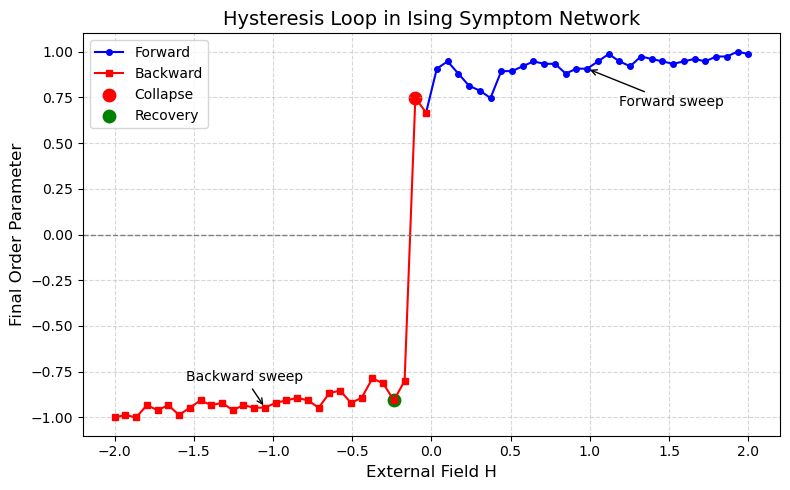

In [11]:
mid = len(H_values)//2
H_forward, orders_forward = H_values[:mid+1], final_orders[:mid+1]
H_backward, orders_backward = H_values[mid:], final_orders[mid:]

plt.figure(figsize=(8,5))

# forward & backward sweeps
plt.plot(H_forward, orders_forward, 'o-', color='blue', label='Forward', linewidth=1.5, markersize=4)
plt.plot(H_backward, orders_backward, 's-', color='red', label='Backward', linewidth=1.5, markersize=4)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # zero line horizontal 

plt.annotate('Forward sweep', xy=(H_forward[len(H_forward)//2], orders_forward[len(orders_forward)//2]),
             xytext=(H_forward[len(H_forward)//2]+0.2, max(orders_forward)*0.7),
             arrowprops=dict(facecolor='blue', arrowstyle='->'), fontsize=10)

plt.annotate('Backward sweep', xy=(H_backward[len(H_backward)//2], orders_backward[len(orders_backward)//2]),
             xytext=(H_backward[len(H_backward)//2]-0.5, min(orders_backward)*0.8),
             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=10)

plt.scatter(H_collapse, final_orders[collapse_idx], color='red', s=80, label='Collapse')
plt.scatter(H_recovery, final_orders[recovery_idx], color='green', s=80, label='Recovery')

plt.title('Hysteresis Loop in Ising Symptom Network', fontsize=14)
plt.xlabel('External Field H', fontsize=12)
plt.ylabel('Final Order Parameter', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

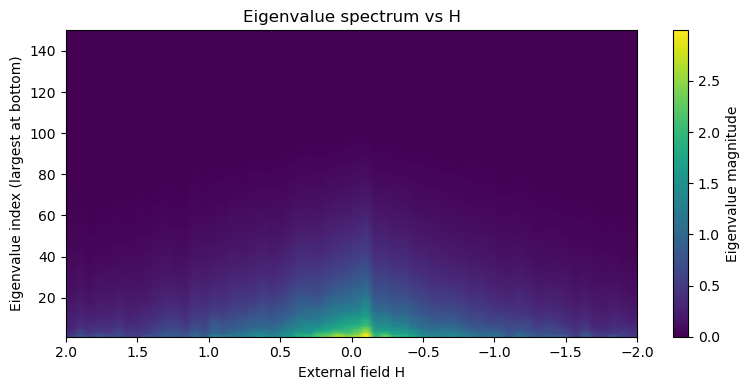

In [12]:
# plot eigenvalue spectrum vs h
plt.figure(figsize=(8,4))
plt.imshow(
    eigen_spectrum.T,                
    aspect='auto',
    extent=[H_values[0], H_values[-1], 1, G.number_of_nodes()],
    origin='lower',
    cmap='viridis'
)
plt.colorbar(label='Eigenvalue magnitude')
plt.xlabel('External field H')
plt.ylabel('Eigenvalue index (largest at bottom)')
plt.title('Eigenvalue spectrum vs H')
plt.tight_layout()
plt.show()

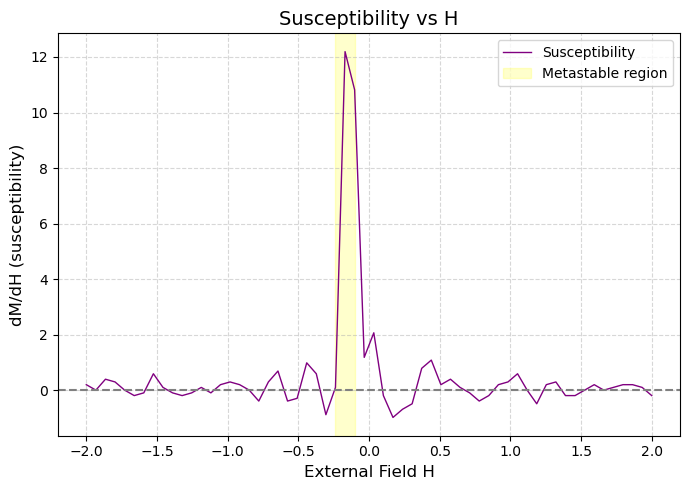

In [13]:
# how susceptible the system is to small changes in H
susceptibility = np.gradient(final_orders, H_values)

plt.figure(figsize=(7,5))  # bigger figure

plt.plot(H_values, susceptibility, 'purple', linewidth=1, label='Susceptibility')

# Shade the metastable region
plt.axvspan(H_recovery, H_collapse, color='yellow', alpha=0.2, label='Metastable region')

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('External Field H', fontsize=12)
plt.ylabel('dM/dH (susceptibility)', fontsize=12)
plt.title('Susceptibility vs H', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Parameter sweep J

In [14]:
T = 2.269
length = 800
warmup = 100

# sweep J from 0 to 3 
J_values = np.linspace(0, 3.0, 60)
final_orders_J = []

initial_state = None

for i, J in enumerate(J_values):
    model = IsingSimulation(
        G,
        H=0,           # no external stress
        J=J,
        T=T,
        length=length,
        warmup=warmup,
        initial_state=initial_state
    )
    
    model.run(delta_H=None)
    final_orders_J.append(model.order_history[-1])
    
    # for potential hysteresis
    initial_state = model.current_state.copy()

final_orders_J = np.array(final_orders_J)

# susceptibility
susceptibility_J = np.gradient(final_orders_J, J_values)

# critical J as max slope
critical_idx = np.argmax(susceptibility_J)
critical_J = J_values[critical_idx]

print(f"Critical J (max dM/dJ) ≈ {critical_J:.3f}")

Critical J (max dM/dJ) ≈ 0.254


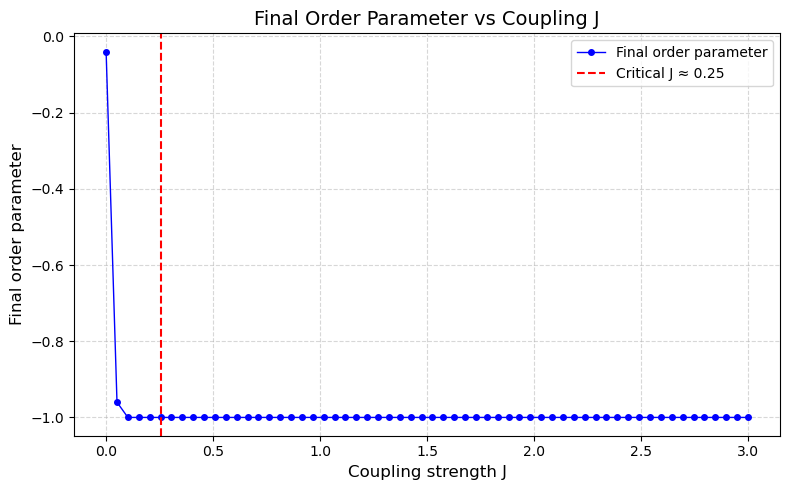

In [15]:
# plot final order vs J
plt.figure(figsize=(8,5))
plt.plot(J_values, final_orders_J, 'b-o', linewidth=1, markersize=4, label='Final order parameter')
plt.axvline(critical_J, color='red', linestyle='--', linewidth=1.5, label=f'Critical J ≈ {critical_J:.2f}')
plt.xlabel('Coupling strength J', fontsize=12)
plt.ylabel('Final order parameter', fontsize=12)
plt.title('Final Order Parameter vs Coupling J', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
num_nodes = G.number_of_nodes()
eigen_spectrum_J = np.zeros((len(J_values), num_nodes))
cov_matrices_all_J = []

initial_state = None

for i, J in enumerate(J_values):
    model = IsingSimulation(
        G,
        H=0,
        J=J,
        T=T,
        length=length,
        warmup=warmup,
        initial_state=initial_state
    )
    model.run(delta_H=None)
    
    cov = model.covariance_matrices(window=100)[-1]  # take last timestep
    cov_matrices_all_J.append(cov)
    
    # eigenvalues
    eigvals = np.linalg.eigvalsh(cov)
    eigen_spectrum_J[i] = eigvals[::-1]  # descending

    # carry forward state
    initial_state = model.current_state.copy()

/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_42836/3305131472.py:209: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_matrices[t] = np.cov(window_states.T)


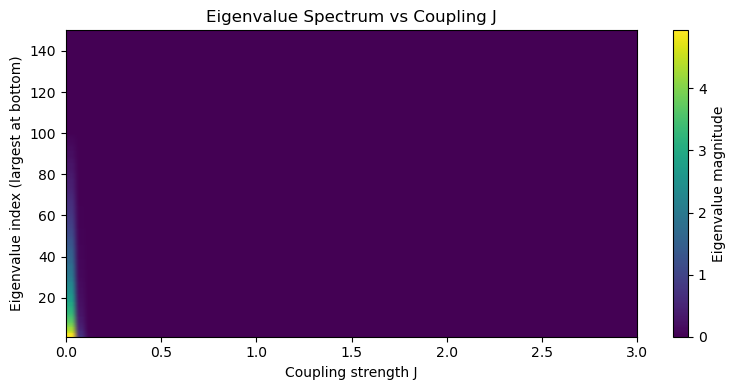

In [17]:
plt.figure(figsize=(8,4))
plt.imshow(
    eigen_spectrum_J.T,
    aspect='auto',
    extent=[J_values[0], J_values[-1], 1, num_nodes],
    origin='lower',
    cmap='viridis'
)
plt.colorbar(label='Eigenvalue magnitude')
plt.xlabel('Coupling strength J')
plt.ylabel('Eigenvalue index (largest at bottom)')
plt.title('Eigenvalue Spectrum vs Coupling J')
plt.tight_layout()
plt.show()

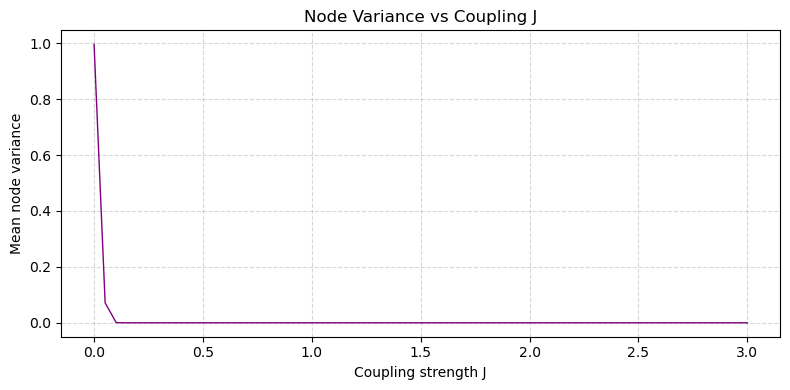

In [18]:
node_variances_J = [np.mean(np.diag(cov)) for cov in cov_matrices_all_J]

plt.figure(figsize=(8,4))
plt.plot(J_values, node_variances_J, 'purple', linewidth=1)
plt.xlabel('Coupling strength J')
plt.ylabel('Mean node variance')
plt.title('Node Variance vs Coupling J')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


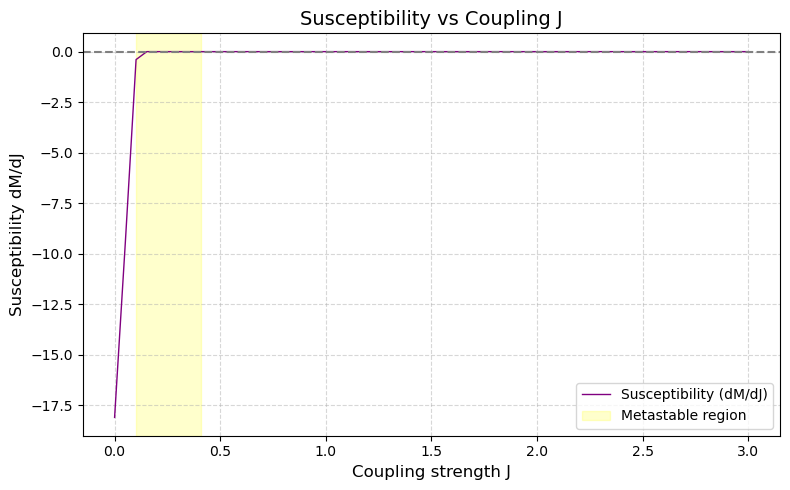

In [19]:
susceptibility_J = np.gradient(final_orders_J, J_values)

peak_idx = np.argmax(susceptibility_J)
meta_start = max(0, int(peak_idx - 3))
meta_end = min(len(J_values)-1, int(peak_idx + 3))

plt.figure(figsize=(8,5))
plt.plot(J_values, susceptibility_J, 'purple', linewidth=1, label='Susceptibility (dM/dJ)')

plt.axvspan(J_values[meta_start], J_values[meta_end], color='yellow', alpha=0.2, label='Metastable region')

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Coupling strength J', fontsize=12)
plt.ylabel('Susceptibility dM/dJ', fontsize=12)
plt.title('Susceptibility vs Coupling J', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Investigate stochastic effects

In [20]:
# run several iterations of the simulation at, near, and far from the CP using both high and low noise.
# plot results including mean and variance.
# TODO: @Kyle

### Hysteresis check

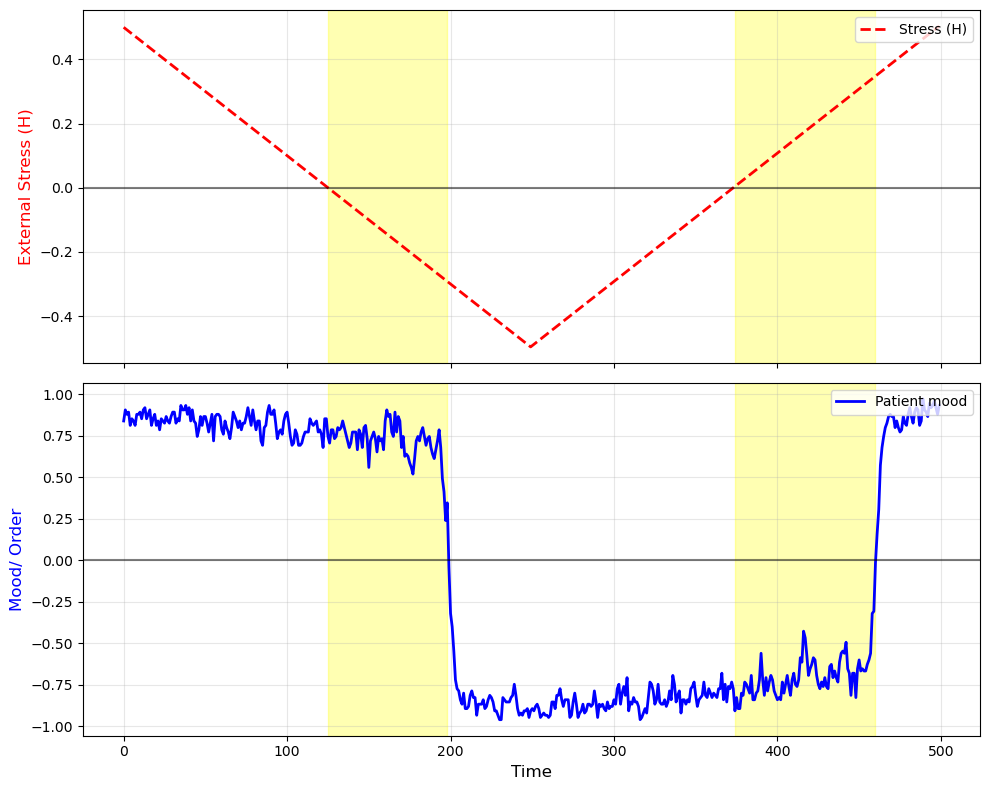

fps: 11


Saving video: 100%|██████████| 500/500 [03:22<00:00,  2.47it/s]


Video saved successfully.


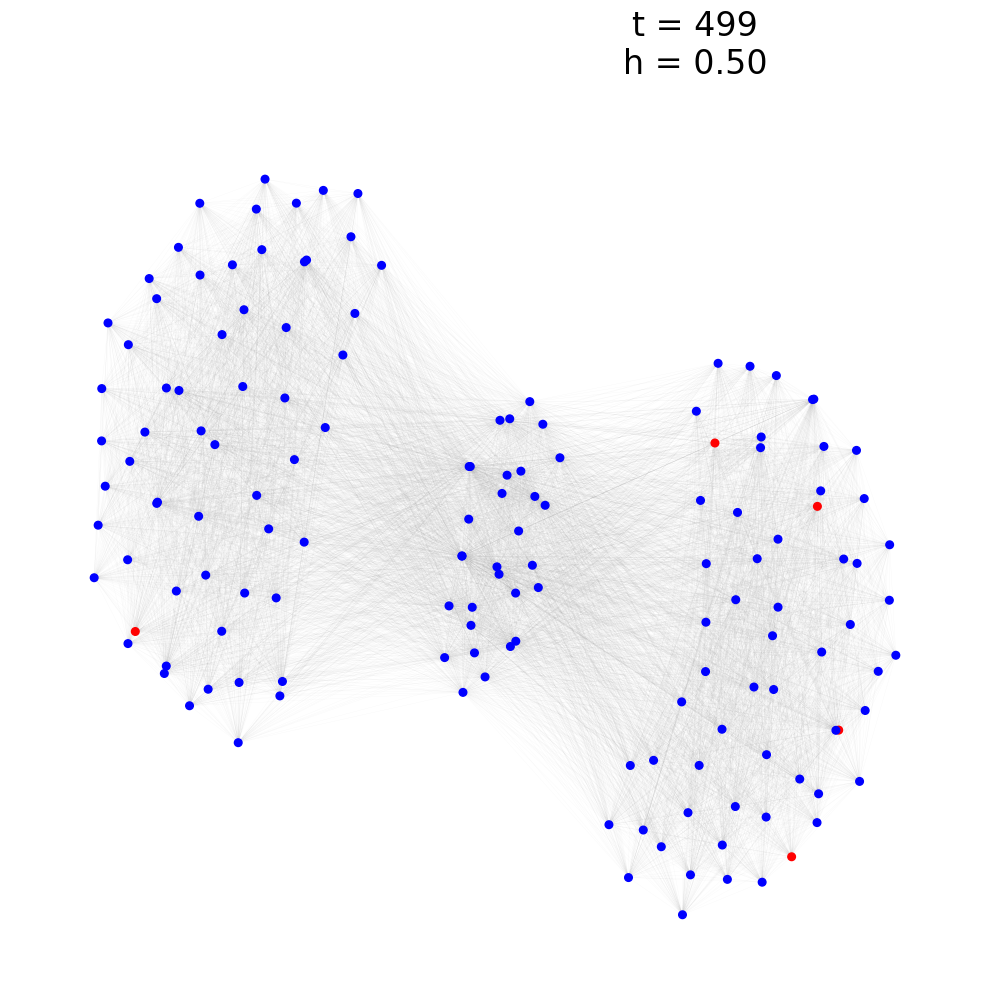

In [21]:
# use the delta_h parameter in the run function to slowly increase h past the critical point, then reduce back to starting value.
# plot the order parameter and h as a function of time.
# answers H5

model = IsingSimulation(G, H=0.5, J=None, T=2.269, length=500, warmup=50)

decrease_H = np.full(model.length//2, -(model.H*2)/(model.length//2))
increase_H = np.full(model.length//2, (model.H*2)/(model.length//2))
delta_H = np.concatenate((decrease_H, increase_H))

model.run(delta_H=delta_H)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# top plot
ax1.plot(model.h_history, color='red', linestyle='--', linewidth=2, label="Stress (H)")
ax1.axhline(0, color='black', alpha=0.5)
ax1.set_ylabel("External Stress (H)", color='red', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')


# Where the outside stress is negative so unhealthy
bad_environment = model.h_history < 0
good_environment = model.h_history > 0

# Where the patients mood is still healthy, bellow 0
good_mood = model.order_history > 0
bad_mood = model.order_history < 0

# The points where the stress is negative but the mood is still positive
metastable_indices = np.where(bad_environment & good_mood)[0]

# If there are any points where the above conditions are valid draw a yelow zone
if len(metastable_indices) > 0:
    start = metastable_indices[0]
    end = metastable_indices[-1]
    ax1.axvspan(start, end, color='yellow', alpha=0.3)

# The points where the stress is positive but the mood is still negative
metastable_indices_2 = np.where(good_environment & bad_mood)[0]

# If there are any points where the above conditions are valid draw a yelow zone
if len(metastable_indices_2) > 0:
    start_2 = metastable_indices_2[0]
    end_2 = metastable_indices_2[-1]
    ax1.axvspan(start_2, end_2, color='yellow', alpha=0.3)

# bottom plot
ax2.plot(model.order_history, color='blue', linewidth=2, label="Patient mood")
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel("Mood/ Order", color='blue', fontsize=12)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# Yellow zone of the bottom graph
if len(metastable_indices) > 0:
    ax2.axvspan(start, end, color='yellow', alpha=0.3)

if len(metastable_indices_2) > 0:
    ax2.axvspan(start_2, end_2, color='yellow', alpha=0.3)


plt.tight_layout()
plt.show()

animate_model(model, filename='./hysteresis.gif', writer='pillow', target_length=45)

/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_42836/2149133125.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')


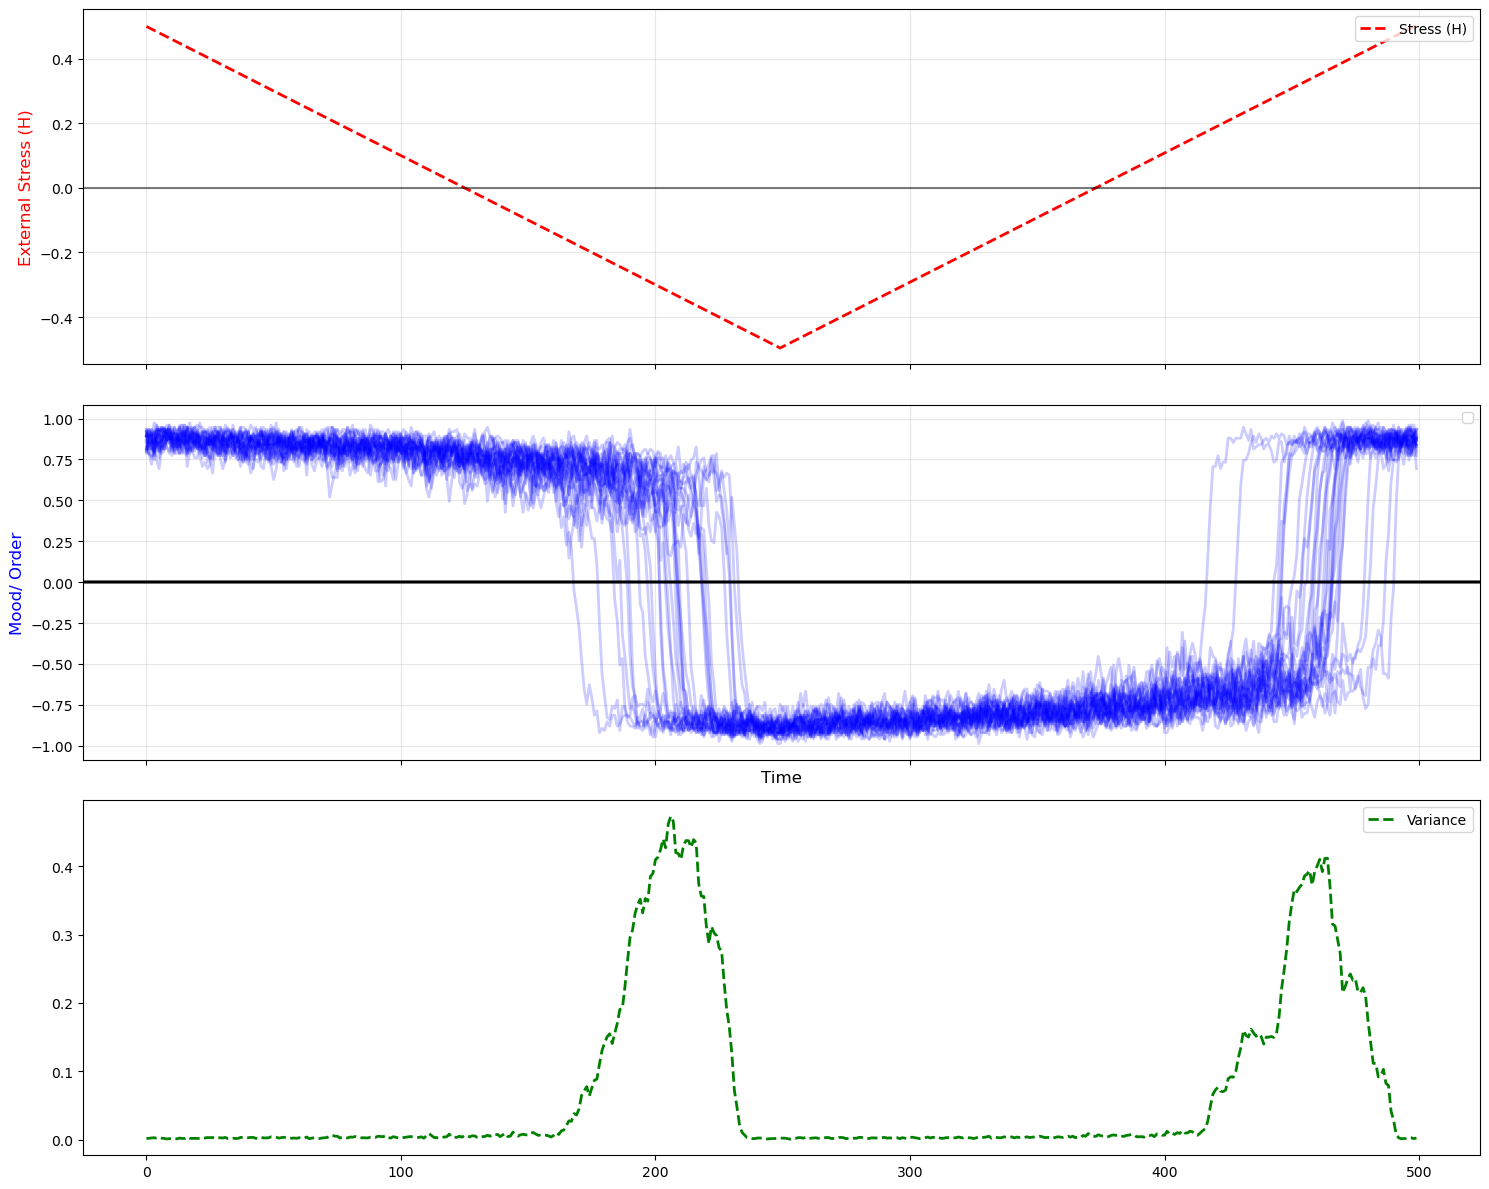

In [22]:
n = 30
models = []
for i in range(n):
    model = IsingSimulation(G, H=0.5, J=None, T=2.269, length=500, warmup=50)
    model.run(delta_H = delta_H)
    models.append(model)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# top plot
ax1.plot(models[0].h_history, color='red', linestyle='--', linewidth=2, label="Stress (H)")
ax1.axhline(0, color='black', alpha=0.5)
ax1.set_ylabel("External Stress (H)", color='red', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

for m in models:
# middle plot
    ax2.plot(m.order_history, color='blue', linewidth=2, alpha=0.2)
    ax2.axhline(0, color='black', alpha=0.5)
    ax2.set_ylabel("Mood/ Order", color='blue', fontsize=12)
    ax2.set_xlabel("Time", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')

orders = np.vstack([m.order_history for m in models])
variance = np.var(orders, axis=0)
ax3.plot(variance, 'g--', linewidth=2, label="Variance")
ax3.legend()


plt.tight_layout()
plt.show()

In [23]:
collapse_1_ts = np.zeros(n)
collapse_2_ts = np.zeros(n)
for i in range(n):
    for j in range(1, models[i].length):
        c1 = 0
        if models[i].order_history[j] * models[i].order_history[j-1] < 0:
            if collapse_1_ts[i] == 0:
                collapse_1_ts[i] = j
            else:
                collapse_2_ts[i] = j
                break

c1_stats = spstats.ttest_1samp(collapse_1_ts, 0, alternative='greater')
c2_stats = spstats.ttest_1samp(collapse_2_ts, 0, alternative='greater')
print(f'p: {c1_stats.pvalue}, F: {c1_stats.statistic}')
print(f'p: {c2_stats.pvalue}, F: {c2_stats.statistic}')


p: 5.782088415994238e-34, F: 68.69768380854394
p: 8.451089843625819e-19, F: 19.978573048807814


In [24]:
# use the delta_h parameter in the run function to slowly increase h past the critical point, then reduce back to starting value.
# plot the order parameter and h as a function of time.
# answers H5
# TODO: @Kyle

### Power Law analysis

Is the system behaving like a critical system governed by scale-free fluctuations, rather than by a characteristic scale?
1. Avalanches (size of mood drops)
2. Spatial perlocation (symptom cluster sizes)

#### 1. Avalanches 

In [25]:
model = IsingSimulation(
    G,
    H=1.5,
    J=None,
    T=2.269,
    length=3000,
    warmup=100
)

# slowly increase stress so system approaches collapse
model.run(delta_H=-0.002)

m = model.order_history

In [26]:
def extract_avalanches(order_history, min_size=1e-4):
    """
    Extract avalanche sizes from the order parameter time series.
    
    Avalanche = contiguous decrease in mood.
    Size = total drop during that episode.
    """
    avalanches = []
    in_avalanche = False
    start_value = None

    for t in range(1, len(order_history)):
        if order_history[t] < order_history[t - 1]:
            if not in_avalanche:
                in_avalanche = True
                start_value = order_history[t - 1]
        else:
            if in_avalanche:
                end_value = order_history[t - 1]
                size = start_value - end_value
                if size > min_size:
                    avalanches.append(size)
                in_avalanche = False

    return np.array(avalanches)

In [27]:
avalanches = extract_avalanches(m)

print(f"Number of avalanches: {len(avalanches)}")
print(f"Min size: {avalanches.min():.4e}")
print(f"Max size: {avalanches.max():.4e}")

Number of avalanches: 785
Min size: 1.3333e-02
Max size: 1.5733e+00


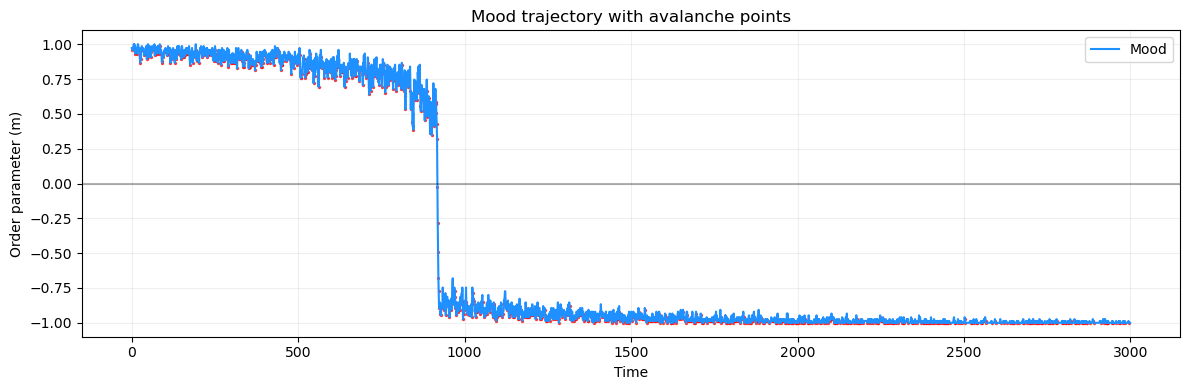

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(m, color='dodgerblue', linewidth=1.5, label='Mood')

# mark avalanche starts
for t in range(1, len(m)):
    if m[t] < m[t-1]:
        plt.scatter(t, m[t], s=2, color='red', alpha=0.7)

plt.axhline(0, color='black', alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Order parameter (m)")
plt.title("Mood trajectory with avalanche points")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [29]:
# log-spaced bins
bins = np.logspace(
    np.log10(avalanches.min()),
    np.log10(avalanches.max()),
    25
)

hist, edges = np.histogram(avalanches, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

In [30]:
# remove empty bins
mask = hist > 0
x = centers[mask]
y = hist[mask]

logx = np.log(x)
logy = np.log(y)

# linear fit
slope, intercept = np.polyfit(logx, logy, 1)
alpha = -slope

print(f"Estimated power-law exponent α ≈ {alpha:.2f}")

Estimated power-law exponent α ≈ 2.21


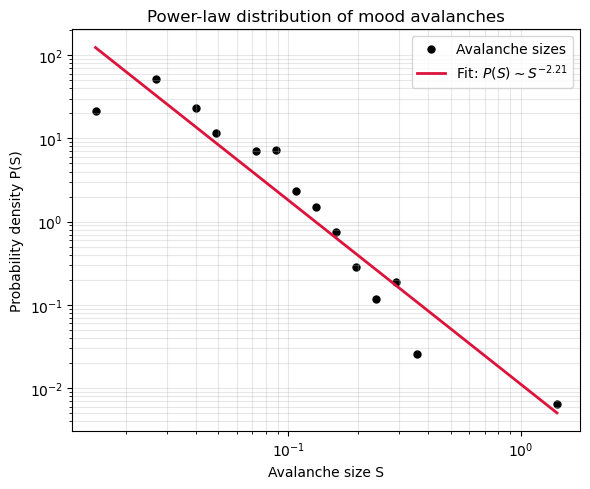

In [31]:
plt.figure(figsize=(6, 5))

plt.scatter(x, y, color='black', s=25, label='Avalanche sizes')
plt.plot(
    x,
    np.exp(intercept) * x**slope,
    color='crimson',
    linewidth=2,
    label=rf'Fit: $P(S) \sim S^{{-{alpha:.2f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Avalanche size S")
plt.ylabel("Probability density P(S)")
plt.title("Power-law distribution of mood avalanches")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Spatial perlocation 

When symptoms are “active”, do they form clusters whose size distribution becomes scale-free near the tipping point?

In [32]:
model = IsingSimulation(
    G,
    H=1.5,
    J=None,
    T=2.269,
    length=3000,
    warmup=100
)

model.run(delta_H=-0.002)

states = model.history        # shape: (time, nodes)
mood = model.order_history

In [33]:
def get_negative_spin_clusters(state, graph):
    """
    Given a spin state and a graph, return sizes of connected
    components formed by nodes with spin = -1.
    """
    # nodes that are 'active' (depressed)
    active_nodes = [i for i, s in enumerate(state) if s == -1]

    if len(active_nodes) == 0:
        return []

    # induced subgraph
    subgraph = graph.subgraph(active_nodes)

    # connected component sizes
    cluster_sizes = [len(c) for c in nx.connected_components(subgraph)]

    return cluster_sizes

In [34]:
def collect_cluster_sizes(states, graph, start_time=0):
    """
    Collect all cluster sizes from start_time to end.
    """
    all_clusters = []

    for t in range(start_time, len(states)):
        clusters = get_negative_spin_clusters(states[t], graph)
        all_clusters.extend(clusters)

    return np.array(all_clusters)

In [35]:
# focus on metastable regime
critical_window_start = np.where(mood < 0.8)[0][0]

cluster_sizes = collect_cluster_sizes(
    states,
    G,
    start_time=critical_window_start
)

print(f"Collected {len(cluster_sizes)} clusters")
print(f"Max cluster size: {cluster_sizes.max()}")

Collected 2977 clusters
Max cluster size: 150


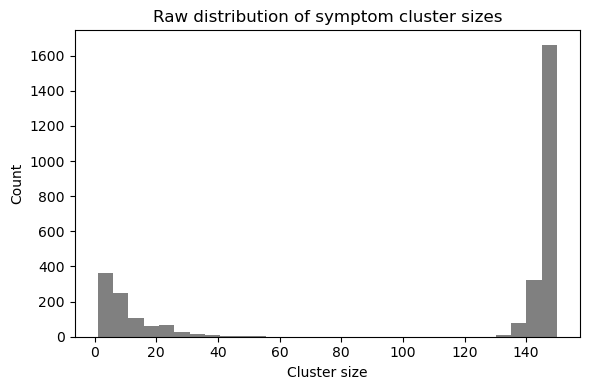

In [36]:
plt.figure(figsize=(6, 4))
plt.hist(cluster_sizes, bins=30, color='gray')
plt.xlabel("Cluster size")
plt.ylabel("Count")
plt.title("Raw distribution of symptom cluster sizes")
plt.tight_layout()
plt.show()

In [37]:
bins = np.logspace(
    np.log10(cluster_sizes.min()),
    np.log10(cluster_sizes.max()),
    25
)

hist, edges = np.histogram(cluster_sizes, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

# fit power law
mask = hist > 0
x = centers[mask]
y = hist[mask]

logx = np.log(x)
logy = np.log(y)

slope, intercept = np.polyfit(logx, logy, 1)
tau = -slope

print(f"Estimated cluster-size exponent τ ≈ {tau:.2f}")

Estimated cluster-size exponent τ ≈ 1.56


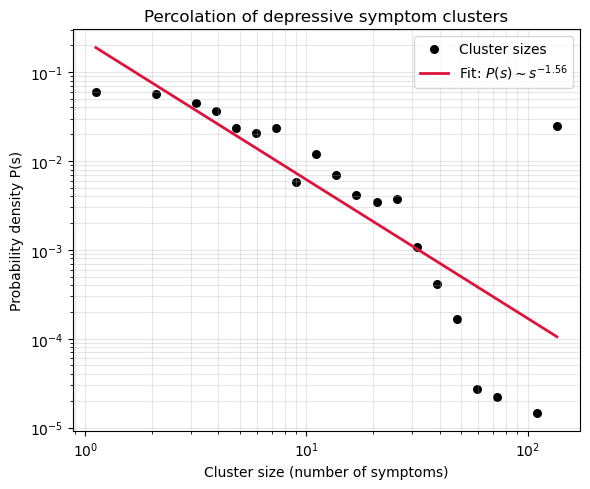

In [38]:
plt.figure(figsize=(6, 5))

plt.scatter(x, y, s=30, color='black', label='Cluster sizes')
plt.plot(
    x,
    np.exp(intercept) * x**slope,
    color='crimson',
    linewidth=2,
    label=rf'Fit: $P(s) \sim s^{{-{tau:.2f}}}$'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Cluster size (number of symptoms)")
plt.ylabel("Probability density P(s)")
plt.title("Percolation of depressive symptom clusters")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# perform power law analysis, drawing inspiration from percolation theory
# TODO: @Julia

## Research Questions

In [40]:
# RQ1: To what extent can the largest eigenvalue of the symptom covariance matrix (σ1) predict critical transitions from a "healthy" to a "depressed" state within a simulated symptom network?
# slowly increase h past critical point. plot order, largest eigenvalue, and h as a function of time.
# answers H1/H3
# TODO: @Kyle

In [41]:
# H2: for the above simulation, plot dominant eigenvalue as percentage of total variance explained
# TODO: @Igor

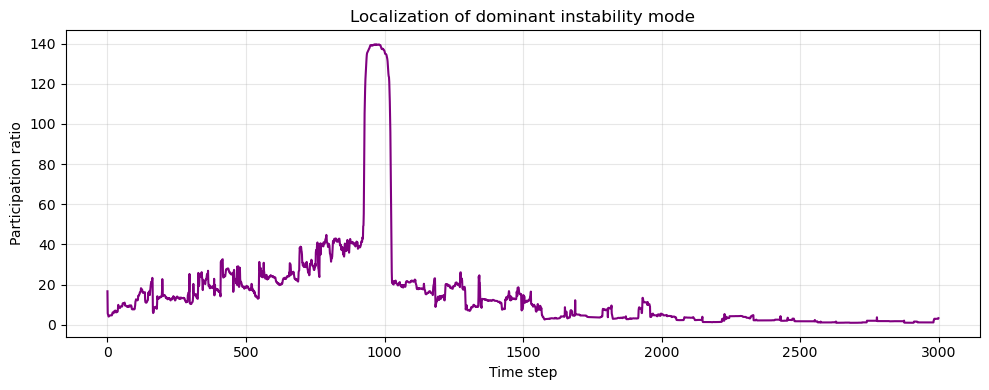

In [42]:
_ = model.covariance_matrices(window=100)  
eigenvalues, eigenvectors = model.sorted_cov_eigens()  

# leading eigenvector at time t:
# v1_t = eigenvectors[t, :, 0]

# participation ratio - localization of instability 

def participation_ratio(v):
    """Measures how concentrated an eigenvector is (low=localized, high=distributed)"""
    return (np.sum(v**2)**2) / np.sum(v**4)

participation = np.array([
    participation_ratio(eigenvectors[t, :, 0])
    for t in range(len(eigenvectors))
])

plt.figure(figsize=(10, 4))
plt.plot(participation, color='purple', linewidth=1.5)
plt.xlabel("Time step")
plt.ylabel("Participation ratio")
plt.title("Localization of dominant instability mode")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation:
* Initially, distress is confined to a few symptoms
* At the tipping point, the entire symptom network becomes unstable simultaneously (cascade)
* After collapse, the system settles into a new (depressed) state with localized activity

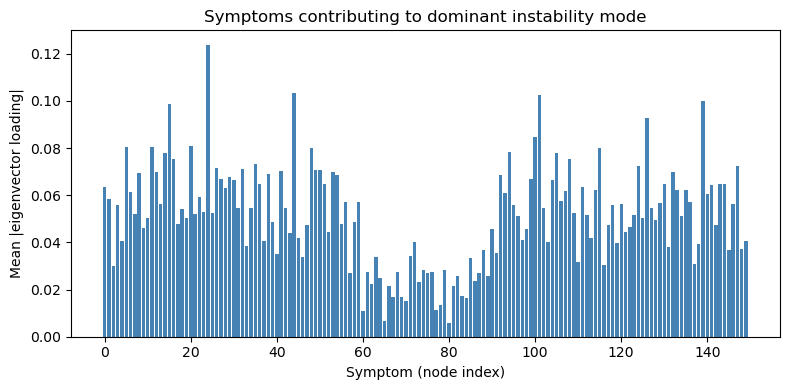

In [43]:
collapse_idx = np.where(model.order_history < -0.5)[0][0]  # first major mood collapse

# average absolute eigenvector loadings of each symptom before collapse
mean_loading = np.mean(
    np.abs(eigenvectors[:collapse_idx, :, 0]),
    axis=0
)
plt.figure(figsize=(8, 4))
plt.bar(range(len(mean_loading)), mean_loading, color='steelblue')
plt.xlabel("Symptom (node index)")
plt.ylabel("Mean |eigenvector loading|")
plt.title("Symptoms contributing to dominant instability mode")
plt.tight_layout()
plt.show()

- no single dominant symptom, but some peaking

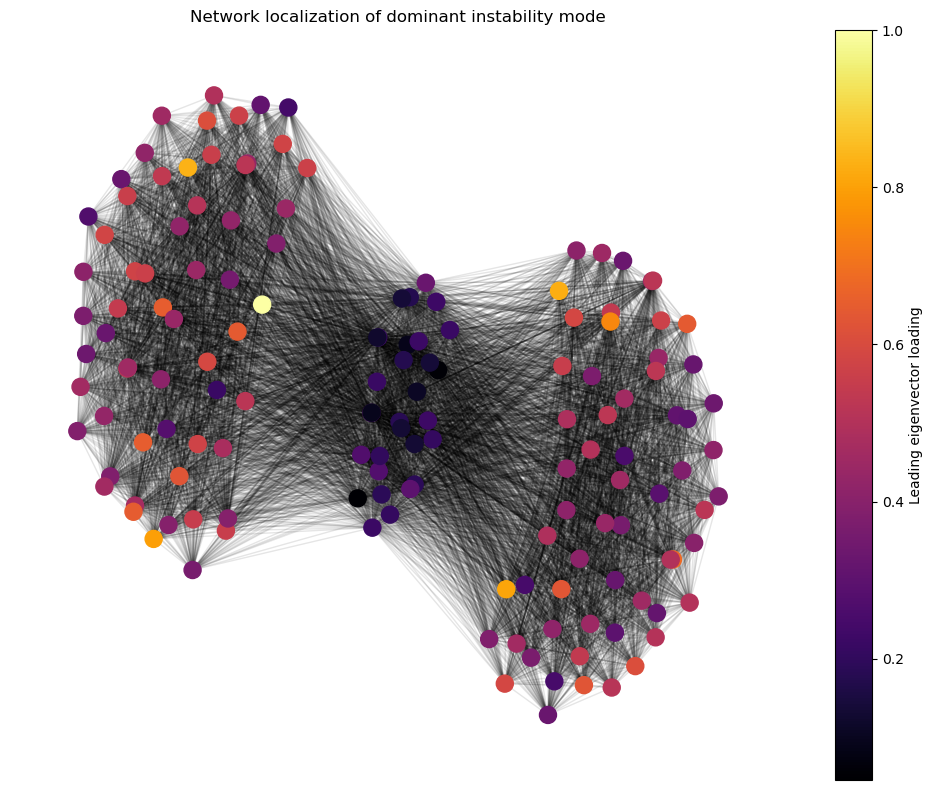

In [44]:
pos = nx.spring_layout(model.network, seed=42)

node_strength = mean_loading / mean_loading.max()  # normalize 0-1

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(model.network, pos, alpha=0.1)
nodes = nx.draw_networkx_nodes(
    model.network,
    pos,
    node_size=150,
    node_color=node_strength,
    cmap='inferno'
)
plt.colorbar(nodes, label="Leading eigenvector loading")
plt.title("Network localization of dominant instability mode")
plt.axis('off')
plt.tight_layout()
plt.show()

- instability concentrated in the symptom groups, not the connections between them
- intuitive interpretation: bridge symptoms - consistently present and common, linking disorders together (e.g. linkling anxiety and depression - common symptoms)
  - higher instability - symptoms rapidly intensifying before a collapse

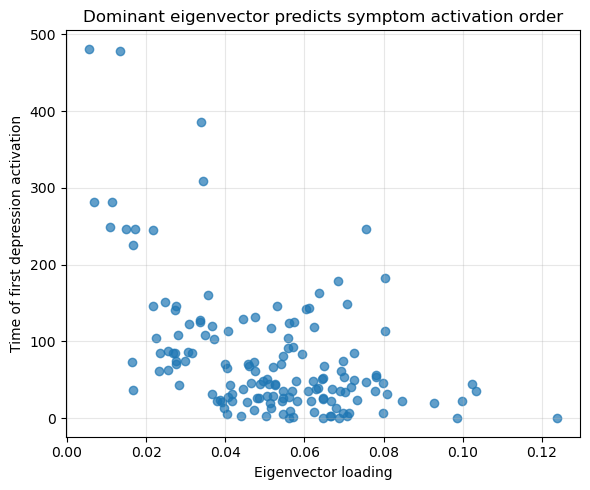

In [45]:
states = model.history  # shape: (time, nodes)
first_negative = np.full(model.network.number_of_nodes(), np.nan)

for t in range(len(states)):
    for i, s in enumerate(states[t]):
        if s == -1 and np.isnan(first_negative[i]):
            first_negative[i] = t

plt.figure(figsize=(6, 5))
plt.scatter(mean_loading, first_negative, alpha=0.7)
plt.xlabel("Eigenvector loading")
plt.ylabel("Time of first depression activation")
plt.title("Dominant eigenvector predicts symptom activation order")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- high loading -> flips early
- low loading -> flips late

### Hypothesis Tests

#### H2: Near CT, the largest eigenvalue of the cov. matrix will increase relative to others, leading to higher proportion of the total variance explained.

Propprtion of variance explained: PVE = largest_eigenval / SUM_all_eigenvalues

Approach: 
1. Break into sliding windows,
2. Compute covariance matrix for each window
3. Extract eigenvalues and compute PVE 
4. Track PVE over time 
5. Is there correlation?

### H3: Covariance-based EWS will effectively signal transitions
Granger causality to see if the largest eigenvalue significantly predicts transitions

In [46]:
n = 50
max_lag = 50
lag_ps = np.ndarray((max_lag, n))

for i in tqdm(range(n)):
    model = IsingSimulation(G, H=1.0, J=0.03, T=2.269, length=200, warmup=50)
    model.run(delta_H=-0.01)

    phase_change_t = -1
    for j in range(1, model.length):
        if model.order_history[j] * model.order_history[j-1] < 0:
            phase_change_t = j
            break

    cov = model.covariance_matrices()
    eig = model.get_early_warning_signal()[phase_change_t-50:phase_change_t]
    order = model.order_history[phase_change_t-50:phase_change_t]
    data = np.column_stack([order, eig])
    results = grangercausalitytests(data, maxlag=max_lag, verbose=False)
    for k, v in results.items():
        f = v[0]['ssr_ftest'][0]
        p = v[0]['ssr_ftest'][1]
        lag_ps[k-1][i] = p

lags = np.arange(1, max_lag+1)
lag_ps_combined = np.zeros(max_lag)
for lag in lags:
    lag_ps_combined[lag-1] = spstats.combine_pvalues(lag_ps[lag-1], method='pearson')[1]

plt.figure(figsize=(10, 5))
plt.bar(lags, lag_ps_combined, label='Combined p-values')
plt.axhline(0.05, color='k', linestyle='--', label='Significance threshold')
plt.xlabel('Lag')
plt.ylabel('p-value')
plt.yscale('log')
plt.title('Significance of lagged correlations')
plt.legend()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
  0%|          | 0/50 [00:01<?, ?it/s]


ValueError: Insufficient observations. Maximum allowable lag is 15

In [ ]:
pct_above_thresh = np.zeros(max_lag)
for i in range(max_lag):
    pct_above_thresh[i] = np.sum(np.where(lag_ps[i] <= 0.05, 1, 0)) / n

plt.figure(figsize=(10, 8))
plt.bar(lags, pct_above_thresh)
plt.xlabel('Lag')
plt.ylabel('Portion of trials above threshold')
plt.title('Portion of trials above threshold')
plt.tight_layout()
plt.show()

In [ ]:
lags_of_interest = [1, 8, 25, 50]
plt.figure(figsize=(10,10))
for i, lag_of_interest in enumerate(lags_of_interest):
    ps = lag_ps[lag_of_interest-1]
    plt.subplot(2, 2, i+1)
    plt.hist(ps, bins=np.arange(0, 1, 0.025))
    plt.axvline(0.05, color='k', linestyle='--', label='Significance threshold')
    plt.xlabel('p-value')
    plt.ylabel('Count')
    plt.title(f'Distribution of p-values, lag={lag_of_interest}')